In [33]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.config import project_io, secrets
from src.spotify_handler import SpotifyHandler
from src.database import SpotifyDB

In [34]:
db = SpotifyDB(db_path=secrets.database_url)

In [37]:
enriched_streams = db.query("SELECT * FROM enriched_streams ORDER BY [timestamp] DESC").df()
enriched_streams.head()

,timestamp,platform,ms_played,country,ip_address,track_name,artist_name,album_name,track_uri,episode_name,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year_audio,release_date
0,2026-03-07 03:54:22,ios,7610,US,2600:4040:a3b9:5b00:544a:68e4:3d5d:ea72,Don't Stop,HoneyLuv,Don't Stop,spotify:track:2JgqwzlOSIxq5WmXKJdnVp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-06 22:51:43,ios,5760,US,108.46.165.234,I’ll Stand By You (feat. Blythe),LP Giobbi,Femme House Vol. 3,spotify:track:0zwjijKrWJMpB8VNa0LTd0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-06 22:51:37,ios,2000,US,108.46.165.234,Just Friends,Honey Dijon,Just Friends,spotify:track:16vvU2dfM73xN57mFlQ9FF,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-06 22:51:35,ios,2610,US,108.46.165.234,Talk To You,ANOTR,Talk To You,spotify:track:0kl6Ozan3fuUdCl6TlB15v,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-06 22:51:31,ios,7710,US,108.46.165.234,Stomp Your Feet,Hannah Laing,Stomp Your Feet,spotify:track:494lD6w8j07gDMub1UFd07,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Songs Listened Per Year'}, xlabel='year_stream'>

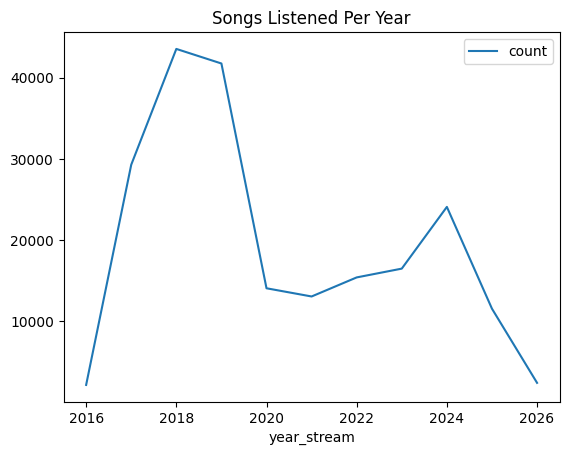

In [38]:
# How many songs did I listen to each year?
songs_per_year = enriched_streams.groupby("year_stream").size().reset_index(name="count")
songs_per_year.plot(x="year_stream", y="count", kind="line", title="Songs Listened Per Year")

<Axes: title={'center': 'Distribution of Milliseconds Played'}>

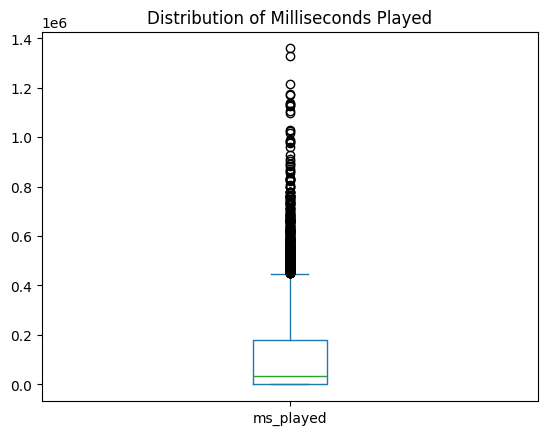

In [69]:
# For how long do I listen to each song?
# Let's create a boxplot to visualize the distribution of ms_played
enriched_streams.plot(y="ms_played", kind="box", title="Distribution of Milliseconds Played")

In [66]:
enriched_streams[['duration_played', 'ms_played']]

,duration_played,ms_played
163,NaT,1600
164,0 days 00:00:26,33170
165,0 days 00:29:05,174765
166,0 days 00:02:56,245174
167,0 days 00:04:06,214208
...,...,...
213875,0 days 00:33:20,14279
213876,0 days 00:00:16,5804
213877,0 days 00:00:06,81570
213886,0 days 00:12:05,1253


In [68]:
# Covert milliseconds to seconds
enriched_streams['ms_played'] / 1000

163         1.600
164        33.170
165       174.765
166       245.174
167       214.208
           ...   
213875     14.279
213876      5.804
213877     81.570
213886      1.253
213889    219.753
Name: ms_played, Length: 37002, dtype: float64

The count of non-nulls shows that there are ~37k records with song information. Though this is a large loss from the initial ~214k songs that were in my export, it is enough to perform meaningful analyses

In [ ]:
audio_cols = [col for col in enriched_streams.columns if col.startswith("audio_")]
episode_cols = [col for col in enriched_streams.columns if col.startswith("episode_")]
enriched_streams = enriched_streams.dropna(subset=["energy"]).drop(
    columns=audio_cols + episode_cols
)

## EDA